# MDN Confidence Interval Visualization

This notebook visualizes the uncertainty estimates from the GeoBERT MDN model.
For each prediction, we show concentric confidence circles (50%, 80%, 95%) around
the deterministic prediction, allowing us to see how confident the model is.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import folium
from folium.plugins import HeatMap

from geobert import Inferencer
from geobert.metrics import haversine_distance_m

pd.set_option('display.max_columns', None)
%matplotlib inline

## Configuration

In [2]:
# Paths
CHECKPOINT_DIR = Path("../outputs/mdn_checkpoints")
TEST_DATA_PATH = CHECKPOINT_DIR / "test_data.parquet"

# NYC center for maps
NYC_CENTER = [40.7128, -74.0060]

# Confidence levels and their z-scores (for normal distribution)
CONFIDENCE_LEVELS = {
    0.50: 0.6745,   # 50% CI
    0.80: 1.2816,   # 80% CI
    0.95: 1.9600,   # 95% CI
}

# Circle colors and opacity for each confidence level
CONFIDENCE_STYLES = {
    0.50: {'color': 'blue', 'opacity': 0.4, 'fill_opacity': 0.2},
    0.80: {'color': 'blue', 'opacity': 0.3, 'fill_opacity': 0.1},
    0.95: {'color': 'blue', 'opacity': 0.2, 'fill_opacity': 0.05},
}

# Approximate degrees to meters conversion at NYC latitude (~40.7°N)
# 1 degree latitude ≈ 111,320 meters
# 1 degree longitude ≈ 111,320 * cos(40.7°) ≈ 84,400 meters
DEG_LAT_TO_M = 111320
DEG_LON_TO_M = 84400

# Number of samples to visualize (keep small for interactive map performance)
N_SAMPLES = 500

## 1. Load MDN Model and Test Data

In [3]:
# Load inferencer with MDN model
print(f"Loading MDN model from: {CHECKPOINT_DIR}")
inferencer = Inferencer(CHECKPOINT_DIR, model_type="mdn")
print(f"Model loaded on device: {inferencer.device}")

Loading MDN model from: ../outputs/mdn_checkpoints
Model loaded on device: cpu


In [4]:
# Load test data
print(f"Loading test data from: {TEST_DATA_PATH}")
test_df = pd.read_parquet(TEST_DATA_PATH)
test_df = test_df.sample(n=N_SAMPLES, random_state=42).reset_index(drop=True)
print(f"Sampled {len(test_df):,} addresses for visualization")
test_df.head()

Loading test data from: ../outputs/mdn_checkpoints/test_data.parquet
Sampled 500 addresses for visualization


,address,latitude,longitude
0,"422 BURNS ST, Queens, NY 11375",40.712711,-73.834969
1,"21 ALEXANDER AVE, Staten Island, NY 10312",40.557957,-74.179550
2,"67 COUNTRY DR N, Staten Island, NY 10314",40.588566,-74.163322
3,"85 BRICKTOWN WAY, Staten Island, NY 10309",40.530022,-74.229271
4,"227-22 67 AVE, Queens, NY 11364",40.746822,-73.748398


## 2. Run MDN Inference with Raw Outputs

In [5]:
# Run inference with raw MDN outputs
addresses = test_df['address'].tolist()
results = inferencer.predict_mdn_raw(addresses)

# Add predictions to dataframe
test_df['pred_lat'] = results['lat']
test_df['pred_lon'] = results['lon']
test_df['sigma_lat'] = results['sigma_lat']
test_df['sigma_lon'] = results['sigma_lon']

# Calculate error distances
actual_lats = torch.tensor(test_df['latitude'].values)
actual_lons = torch.tensor(test_df['longitude'].values)
pred_lats = torch.tensor(test_df['pred_lat'].values)
pred_lons = torch.tensor(test_df['pred_lon'].values)

distances_m = haversine_distance_m(actual_lats, actual_lons, pred_lats, pred_lons)
test_df['error_m'] = distances_m.numpy()

# Calculate sigma in meters (using max of lat/lon for circular representation)
test_df['sigma_lat_m'] = test_df['sigma_lat'] * DEG_LAT_TO_M
test_df['sigma_lon_m'] = test_df['sigma_lon'] * DEG_LON_TO_M
test_df['sigma_max_m'] = np.maximum(test_df['sigma_lat_m'], test_df['sigma_lon_m'])

print("Sample predictions with uncertainty:")
test_df[['address', 'pred_lat', 'pred_lon', 'sigma_lat', 'sigma_lon', 'sigma_max_m', 'error_m']].head(10)

Tokenizing addresses...
Running MDN inference...
Sampling from MDN...
Denormalizing predictions...
Sample predictions with uncertainty:


,address,pred_lat,pred_lon,sigma_lat,sigma_lon,sigma_max_m,error_m
0,"422 BURNS ST, Queens, NY 11375",40.715054,-73.843307,0.004756,0.005217,529.480103,749.534546
1,"21 ALEXANDER AVE, Staten Island, NY 10312",40.552586,-74.187698,0.004932,0.005679,549.051208,911.357544
2,"67 COUNTRY DR N, Staten Island, NY 10314",40.587555,-74.176147,0.005797,0.008207,692.652771,1088.790161
3,"85 BRICKTOWN WAY, Staten Island, NY 10309",40.523399,-74.232018,0.007986,0.008772,889.053528,772.092346
4,"227-22 67 AVE, Queens, NY 11364",40.748875,-73.744926,0.002812,0.003211,313.022919,370.934937
5,"314 E 184 ST, Bronx, NY 10458",40.864880,-73.894127,0.004685,0.005023,521.545532,756.793396
6,"133-05 230 ST, Queens, NY 11413",40.674652,-73.735886,0.003458,0.003134,384.898773,429.250122
7,"506 ONDERDONK AVE, Queens, NY 11385",40.707916,-73.913368,0.003147,0.005145,434.208282,280.427917
8,"743 WOOLLEY AVE, Staten Island, NY 10314",40.614517,-74.144012,0.005093,0.007181,606.035889,1141.120117
9,"135-01 233 ST, Queens, NY 11422",40.666954,-73.730232,0.004551,0.004029,506.636597,933.854675


## 3. Uncertainty Statistics

In [6]:
print("=" * 60)
print("UNCERTAINTY STATISTICS")
print("=" * 60)

print(f"\nSigma (degrees):")
print(f"  Latitude  - Mean: {test_df['sigma_lat'].mean():.6f}, Std: {test_df['sigma_lat'].std():.6f}")
print(f"  Longitude - Mean: {test_df['sigma_lon'].mean():.6f}, Std: {test_df['sigma_lon'].std():.6f}")

print(f"\nSigma (meters):")
print(f"  Max sigma - Mean: {test_df['sigma_max_m'].mean():.1f}m, Median: {test_df['sigma_max_m'].median():.1f}m")
print(f"  Max sigma - Min: {test_df['sigma_max_m'].min():.1f}m, Max: {test_df['sigma_max_m'].max():.1f}m")

print(f"\nPrediction Error:")
print(f"  Mean: {test_df['error_m'].mean():.1f}m, Median: {test_df['error_m'].median():.1f}m")

# Correlation between sigma and error (calibration check)
correlation = test_df['sigma_max_m'].corr(test_df['error_m'])
print(f"\nCalibration:")
print(f"  Correlation(sigma, error): {correlation:.3f}")
print(f"  (Positive correlation suggests model uncertainty is calibrated)")
print("=" * 60)

UNCERTAINTY STATISTICS

Sigma (degrees):
  Latitude  - Mean: 0.003994, Std: 0.001133
  Longitude - Mean: 0.004961, Std: 0.001534

Sigma (meters):
  Max sigma - Mean: 481.0m, Median: 463.0m
  Max sigma - Min: 243.9m, Max: 1282.6m

Prediction Error:
  Mean: 516.1m, Median: 416.7m

Calibration:
  Correlation(sigma, error): 0.486
  (Positive correlation suggests model uncertainty is calibrated)


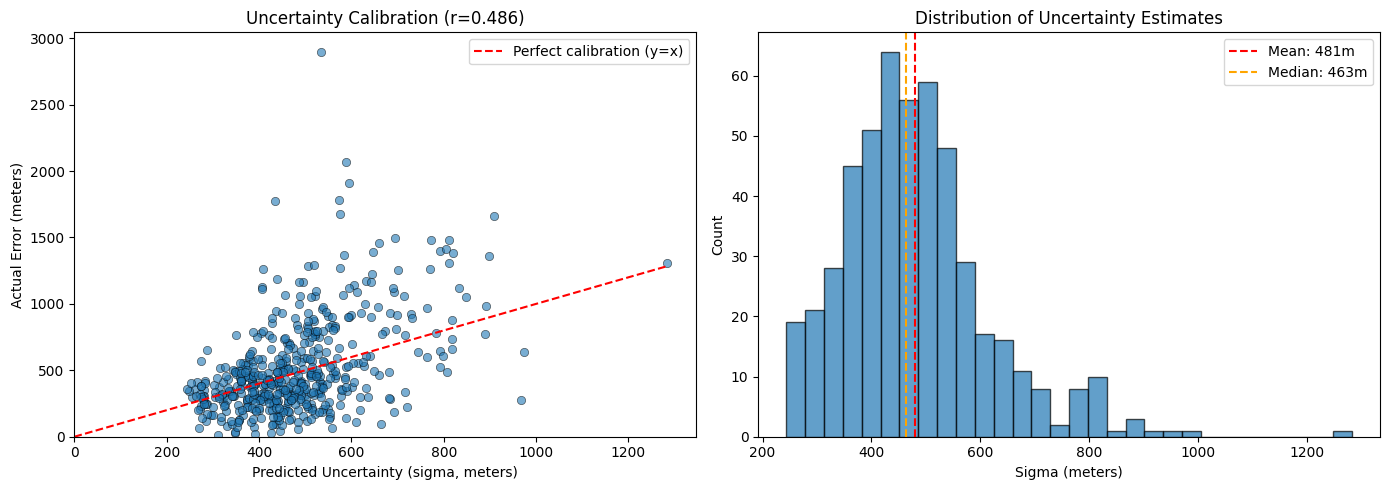

In [7]:
# Calibration plot: sigma vs actual error
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of sigma vs error
axes[0].scatter(test_df['sigma_max_m'], test_df['error_m'], alpha=0.6, edgecolor='black', linewidth=0.5)
axes[0].plot([0, test_df['sigma_max_m'].max()], [0, test_df['sigma_max_m'].max()], 
             'r--', label='Perfect calibration (y=x)')
axes[0].set_xlabel('Predicted Uncertainty (sigma, meters)')
axes[0].set_ylabel('Actual Error (meters)')
axes[0].set_title(f'Uncertainty Calibration (r={correlation:.3f})')
axes[0].legend()
axes[0].set_xlim(0, None)
axes[0].set_ylim(0, None)

# Distribution of sigma values
axes[1].hist(test_df['sigma_max_m'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(test_df['sigma_max_m'].mean(), color='red', linestyle='--', 
                label=f'Mean: {test_df["sigma_max_m"].mean():.0f}m')
axes[1].axvline(test_df['sigma_max_m'].median(), color='orange', linestyle='--', 
                label=f'Median: {test_df["sigma_max_m"].median():.0f}m')
axes[1].set_xlabel('Sigma (meters)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Uncertainty Estimates')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Confidence Circle Visualization

Each prediction is shown with three concentric circles representing:
- **Inner (darkest)**: 50% confidence interval
- **Middle**: 80% confidence interval  
- **Outer (lightest)**: 95% confidence interval

Green markers show the actual locations for comparison.

In [8]:
def create_confidence_map(df, n_samples=30):
    """Create folium map with confidence circles around predictions."""
    
    # Sample if needed
    if len(df) > n_samples:
        df = df.sample(n=n_samples, random_state=42)
    
    # Create map
    m = folium.Map(location=NYC_CENTER, zoom_start=11, tiles='CartoDB positron')
    
    for _, row in df.iterrows():
        pred_loc = [row['pred_lat'], row['pred_lon']]
        actual_loc = [row['latitude'], row['longitude']]
        sigma_m = row['sigma_max_m']
        
        # Draw confidence circles (outer to inner for proper layering)
        for conf_level in sorted(CONFIDENCE_LEVELS.keys(), reverse=True):
            z_score = CONFIDENCE_LEVELS[conf_level]
            style = CONFIDENCE_STYLES[conf_level]
            radius_m = z_score * sigma_m
            
            folium.Circle(
                location=pred_loc,
                radius=radius_m,
                color=style['color'],
                weight=1,
                opacity=style['opacity'],
                fill=True,
                fill_color=style['color'],
                fill_opacity=style['fill_opacity'],
                popup=f"{int(conf_level*100)}% CI: {radius_m:.0f}m radius",
            ).add_to(m)
        
        # Prediction center marker (blue dot)
        folium.CircleMarker(
            location=pred_loc,
            radius=4,
            color='blue',
            fill=True,
            fill_opacity=0.8,
            popup=f"<b>Predicted</b><br>{row['address']}<br>"
                  f"σ_lat: {row['sigma_lat']:.5f}°<br>"
                  f"σ_lon: {row['sigma_lon']:.5f}°<br>"
                  f"σ_max: {sigma_m:.0f}m",
        ).add_to(m)
        
        # Actual location marker (green)
        folium.CircleMarker(
            location=actual_loc,
            radius=5,
            color='green',
            fill=True,
            fill_opacity=0.8,
            popup=f"<b>Actual</b><br>{row['address']}<br>Error: {row['error_m']:.0f}m",
        ).add_to(m)
        
        # Line connecting prediction to actual
        folium.PolyLine(
            [pred_loc, actual_loc],
            color='gray',
            weight=1,
            opacity=0.5,
        ).add_to(m)
    
    # Add legend
    legend_html = '''
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; background-color: white;
                padding: 10px; border: 2px solid gray; border-radius: 5px; font-size: 12px;">
        <b>Legend</b><br>
        <i style="background: green; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Actual location<br>
        <i style="background: blue; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Predicted location<br>
        <hr style="margin: 5px 0;">
        <b>Confidence Circles</b><br>
        <span style="color: blue; opacity: 0.4;">■</span> 50% CI (darkest)<br>
        <span style="color: blue; opacity: 0.3;">■</span> 80% CI<br>
        <span style="color: blue; opacity: 0.2;">■</span> 95% CI (lightest)
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    return m

# Create and display map
confidence_map = create_confidence_map(test_df, n_samples=30)
confidence_map

## 5. Confidence Interval Coverage Analysis

Check if the actual locations fall within the predicted confidence intervals.
For a well-calibrated model:
- ~50% of actual locations should be within the 50% CI
- ~80% of actual locations should be within the 80% CI
- ~95% of actual locations should be within the 95% CI

In [9]:
# Calculate coverage for each confidence level
print("=" * 60)
print("CONFIDENCE INTERVAL COVERAGE")
print("=" * 60)
print(f"{'Level':<10} {'Expected':<12} {'Actual':<12} {'Status'}")
print("-" * 50)

for conf_level, z_score in sorted(CONFIDENCE_LEVELS.items()):
    # Calculate radius for this confidence level
    radius_m = z_score * test_df['sigma_max_m']
    
    # Check if actual error is within the confidence radius
    within_ci = (test_df['error_m'] <= radius_m).mean() * 100
    expected = conf_level * 100
    
    # Determine calibration status
    diff = within_ci - expected
    if abs(diff) < 10:
        status = "✓ Good"
    elif diff > 0:
        status = "⬆ Overconfident" if diff > 20 else "~ Slightly over"
    else:
        status = "⬇ Underconfident" if diff < -20 else "~ Slightly under"
    
    print(f"{int(conf_level*100)}% CI     {expected:.0f}%          {within_ci:.1f}%        {status}")

print("=" * 60)
print("\nNote: 'Overconfident' means model uncertainty is too small (actual errors larger than predicted).")
print("      'Underconfident' means model uncertainty is too large (conservative estimates).")

CONFIDENCE INTERVAL COVERAGE
Level      Expected     Actual       Status
--------------------------------------------------
50% CI     50%          27.0%        ⬇ Underconfident
80% CI     80%          70.0%        ~ Slightly under
95% CI     95%          93.4%        ✓ Good

Note: 'Overconfident' means model uncertainty is too small (actual errors larger than predicted).
      'Underconfident' means model uncertainty is too large (conservative estimates).


## 6. High Uncertainty Predictions

Examine predictions where the model is most uncertain.

In [10]:
# Get top 10 highest uncertainty predictions
high_uncertainty = test_df.nlargest(10, 'sigma_max_m')

print("Top 10 Most Uncertain Predictions:")
print(high_uncertainty[['address', 'sigma_max_m', 'error_m']].to_string(index=False))

Top 10 Most Uncertain Predictions:
                                     address  sigma_max_m     error_m
               958 BAYSIDE, Queens, NY 11697  1282.636841 1308.168945
            325 BCH 145 ST, Queens, NY 11694   972.799988  637.570496
109-20 ROCKAWAY BEACH BLVD, Queens, NY 11694   967.848328  276.814575
      35 SELKIRK ST, Staten Island, NY 10309   909.814514 1663.808594
            6037 HUXLEY AVE, Bronx, NY 10471   898.623230 1363.317505
       69 TOWERS LN, Staten Island, NY 10314   890.880615  984.172241
   85 BRICKTOWN WAY, Staten Island, NY 10309   889.053528  772.092346
      14-72 BCH CHANNEL DR, Queens, NY 11691   848.812439 1050.970337
          606 W  207 ST, Manhattan, NY 10034   831.898987 1118.867554
          517 W  207 ST, Manhattan, NY 10034   819.908447 1379.365845


In [11]:
# Visualize high uncertainty predictions
high_uncertainty_map = create_confidence_map(high_uncertainty, n_samples=10)
high_uncertainty_map

## 7. Error vs Uncertainty Heatmaps

Compare the geographic distribution of prediction errors vs model uncertainty.
Both are normalized to 0-1 scale for direct comparison. Use the layer control
(top right) to toggle between heatmaps.

In [12]:
# Normalize error and uncertainty to 0-1 scale
error_min, error_max = test_df['error_m'].min(), test_df['error_m'].max()
sigma_min, sigma_max = test_df['sigma_max_m'].min(), test_df['sigma_max_m'].max()

test_df['error_norm'] = (test_df['error_m'] - error_min) / (error_max - error_min)
test_df['sigma_norm'] = (test_df['sigma_max_m'] - sigma_min) / (sigma_max - sigma_min)

print(f"Error range: {error_min:.1f}m - {error_max:.1f}m (normalized to 0-1)")
print(f"Sigma range: {sigma_min:.1f}m - {sigma_max:.1f}m (normalized to 0-1)")

# Create heatmap data: [lat, lon, weight]
error_heat_data = [
    [row['latitude'], row['longitude'], row['error_norm']] 
    for _, row in test_df.iterrows()
]
sigma_heat_data = [
    [row['latitude'], row['longitude'], row['sigma_norm']] 
    for _, row in test_df.iterrows()
]

# Create map with layer groups
heatmap_compare = folium.Map(location=NYC_CENTER, zoom_start=11, tiles='CartoDB dark_matter')

# Error heatmap layer
error_layer = folium.FeatureGroup(name='Error Heatmap (normalized 0-1)')
HeatMap(
    error_heat_data,
    min_opacity=0.3,
    radius=15,
    blur=20,
    max_zoom=13,
).add_to(error_layer)
error_layer.add_to(heatmap_compare)

# Uncertainty heatmap layer
uncertainty_layer = folium.FeatureGroup(name='Uncertainty Heatmap (normalized 0-1)', show=False)
HeatMap(
    sigma_heat_data,
    min_opacity=0.3,
    radius=15,
    blur=20,
    max_zoom=13,
).add_to(uncertainty_layer)
uncertainty_layer.add_to(heatmap_compare)

# Add layer control
folium.LayerControl(collapsed=False).add_to(heatmap_compare)

# Add legend/title
legend_html = '''
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%); z-index: 1000; 
            background-color: rgba(0,0,0,0.7); color: white; padding: 10px; border-radius: 5px;">
    <b>Error vs Uncertainty Heatmap</b><br>
    <small>Both normalized to 0-1 scale | Toggle layers in top-right</small><br>
    <small>Brighter = Higher values</small>
</div>
'''
heatmap_compare.get_root().html.add_child(folium.Element(legend_html))

heatmap_compare

Error range: 12.2m - 2898.8m (normalized to 0-1)
Sigma range: 243.9m - 1282.6m (normalized to 0-1)


## 8. Save Maps

In [13]:
# Create output directory
output_dir = Path("../outputs/maps")
output_dir.mkdir(parents=True, exist_ok=True)

maps_to_save = {
    'mdn_confidence_circles.html': confidence_map,
    'mdn_high_uncertainty.html': high_uncertainty_map,
    'mdn_error_uncertainty_heatmap.html': heatmap_compare,
}

for filename, map_obj in maps_to_save.items():
    filepath = output_dir / filename
    map_obj.save(str(filepath))
    print(f"Saved: {filepath}")

Saved: ../outputs/maps/mdn_confidence_circles.html
Saved: ../outputs/maps/mdn_high_uncertainty.html
Saved: ../outputs/maps/mdn_error_uncertainty_heatmap.html


## 9. Summary

In [14]:
print("=" * 60)
print("MDN CONFIDENCE VISUALIZATION SUMMARY")
print("=" * 60)
print(f"\nSamples visualized: {len(test_df)}")
print(f"\nUncertainty (sigma):")
print(f"  Mean: {test_df['sigma_max_m'].mean():.0f}m")
print(f"  Median: {test_df['sigma_max_m'].median():.0f}m")
print(f"\nPrediction Error:")
print(f"  Mean: {test_df['error_m'].mean():.0f}m")
print(f"  Median: {test_df['error_m'].median():.0f}m")
print(f"\nUncertainty-Error Correlation: {correlation:.3f}")
print("=" * 60)

MDN CONFIDENCE VISUALIZATION SUMMARY

Samples visualized: 500

Uncertainty (sigma):
  Mean: 481m
  Median: 463m

Prediction Error:
  Mean: 516m
  Median: 417m

Uncertainty-Error Correlation: 0.486
